In [1]:
!pip install kaggle
!kaggle datasets list | head
!export KAGGLE_API_TOKEN=KGAT_e0d4b880e92a4cb6dfff3ca75770a3d3

  Using cached webencodings-0.5.1-py2.py3-none-any.whl.metadata (2.1 kB)
Using cached webencodings-0.5.1-py2.py3-none-any.whl (11 kB)



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
'head' is not recognized as an internal or external command,
operable program or batch file.
'export' is not recognized as an internal or external command,
operable program or batch file.


In [2]:
import os

os.environ['KAGGLE_USERNAME'] = 'himajachaluvadi'
os.environ['KAGGLE_KEY'] = 'KGAT_e0d4b880e92a4cb6dfff3ca75770a3d3'
!kaggle datasets download -d dasa7753912/new-paddy-doctor-paddy-disease-classification

Dataset URL: https://www.kaggle.com/datasets/dasa7753912/new-paddy-doctor-paddy-disease-classification
License(s): unknown




  0%|          | 0.00/2.17G [00:00<?, ?B/s]
  0%|          | 1.00M/2.17G [00:02<1:22:58, 468kB/s]
  0%|          | 2.00M/2.17G [00:05<1:39:41, 390kB/s]
  0%|          | 3.00M/2.17G [00:05<1:05:37, 591kB/s]
  0%|          | 4.00M/2.17G [00:06<47:37, 815kB/s]  
  0%|          | 5.00M/2.17G [00:06<35:34, 1.09MB/s]
  0%|          | 6.00M/2.17G [00:07<25:22, 1.53MB/s]
  0%|          | 8.00M/2.17G [00:07<14:07, 2.74MB/s]
  0%|          | 10.0M/2.17G [00:07<09:23, 4.12MB/s]
  0%|          | 11.0M/2.17G [00:07<08:20, 4.64MB/s]
  1%|          | 14.0M/2.17G [00:07<05:15, 7.35MB/s]
  1%|          | 16.0M/2.17G [00:07<04:28, 8.61MB/s]
  1%|          | 18.0M/2.17G [00:07<03:58, 9.70MB/s]
  1%|          | 20.0M/2.17G [00:08<03:40, 10.5MB/s]
  1%|          | 22.0M/2.17G [00:08<03:23, 11.3MB/s]
  1%|          | 24.0M/2.17G [00:08<03:13, 11.9MB/s]
  1%|          | 26.0M/2.17G [00:08<03:06, 12.3MB/s]
  1%|▏         | 28.0M/2.17G [00:08<03:23, 11.3MB/s]
  1%|▏         | 30.0M/2.17G [00:08<03:05, 12.4MB/

In [3]:
!unzip new-paddy-doctor-paddy-disease-classification.zip

'unzip' is not recognized as an internal or external command,
operable program or batch file.


In [26]:
from tensorflow.keras.models import load_model

model = load_model('rice_leaf_detector.h5')
print("✅ Model loaded successfully")


✅ Model loaded successfully


In [27]:
import cv2
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt
import os

# Load model
MODEL_PATH = 'C:/Users/LENOVO/Downloads/Major_Project/rice_leaf_detector.h5'  # Replace with your model path
model = load_model(MODEL_PATH)

# Classes
class_names = ['bacterial_leaf_blight','bacterial_leaf_streak','bacterial_panicle_blight',
               'blast','brown_spot','dead_heart','downy_mildew','hispa','normal','tungro']

In [28]:
from tkinter.filedialog import askopenfilename
img_path = 'C:/Users/LENOVO/Downloads/Major_Project/new-paddy-doctor-paddy-disease-classification/paddy-disease-classification/train_images/bacterial_leaf_streak/100042.jpg'

In [29]:
def predict_disease(img_path, model):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    prediction = model.predict(img_array)
    predicted_class = np.argmax(prediction, axis=1)[0]
    return class_names[predicted_class]

In [30]:
def apply_green_mask(img_path, is_normal=False):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    if is_normal:
        return None, None, img  # Skip mask generation for healthy leaves

    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)

    # Green mask
    lower_green = np.array([25, 40, 40])
    upper_green = np.array([85, 255, 255])
    green_mask = cv2.inRange(hsv, lower_green, upper_green)

    # Exclusion masks
    lower_blue = np.array([90, 50, 50])
    upper_blue = np.array([130, 255, 255])
    blue_mask = cv2.inRange(hsv, lower_blue, upper_blue)

    lower_dark = np.array([0, 0, 0])
    upper_dark = np.array([180, 50, 50])
    dark_mask = cv2.inRange(hsv, lower_dark, upper_dark)

    exclude_mask = cv2.bitwise_or(blue_mask, dark_mask)
    refined_green_mask = cv2.bitwise_and(green_mask, cv2.bitwise_not(exclude_mask))

    disease_affected_area = cv2.bitwise_and(img, img, mask=refined_green_mask)
    return disease_affected_area, refined_green_mask, img

In [ ]:
def estimate_severity(img_path):

    leaf_img, mask, original = apply_green_mask(img_path)

    if leaf_img is None or mask is None:
        return "None", 0, original, None

    hsv_leaf = cv2.cvtColor(leaf_img, cv2.COLOR_RGB2HSV)

    lower_disease = np.array([10, 50, 50])
    upper_disease = np.array([30, 255, 255])

    disease_mask = cv2.inRange(hsv_leaf, lower_disease, upper_disease)
    disease_mask = cv2.bitwise_and(disease_mask, disease_mask, mask=mask)

    disease_area = cv2.countNonZero(disease_mask)
    total_leaf_area = cv2.countNonZero(mask)

    if total_leaf_area == 0:
        return "Unknown", 0, original, None

    severity_percent = round((disease_area / total_leaf_area) * 100, 2)

    if severity_percent < 30:
        severity = "Low"
    elif severity_percent < 60:
        severity = "Medium"
    else:
        severity = "High"

    return severity, severity_percent, original, leaf_img

In [32]:
disease = predict_disease(img_path, model)
print("🟢 Predicted Disease:", disease)

if disease.lower() == 'normal':
    print("✅ The leaf is healthy. No severity estimation required.")
    severity = "None"
    percent = 0
    original, affected = cv2.imread(img_path), None
else:
    print("⚠️ Disease detected. Estimating severity...")
    severity, percent, original, affected = estimate_severity(img_path)

print(f"🔍 Severity: {severity} ({percent}%)")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
🟢 Predicted Disease: bacterial_leaf_blight
⚠️ Disease detected. Estimating severity...
🔍 Severity: Low (4.83%)


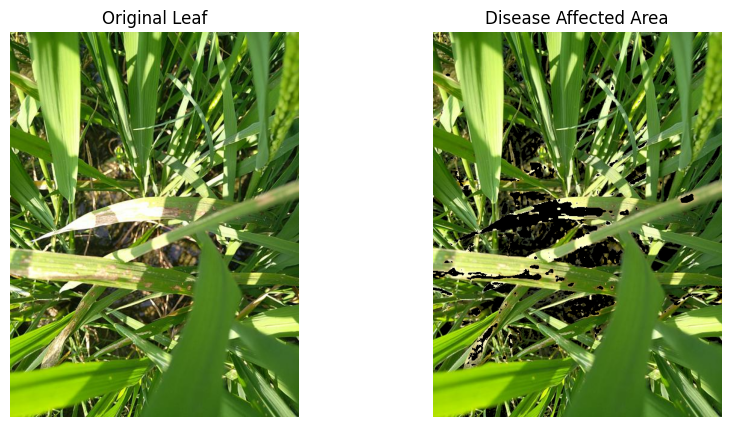

In [33]:
def show_images(original, affected=None):
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(original)
    plt.title("Original Leaf")
    plt.axis('off')

    if affected is not None:
        plt.subplot(1, 2, 2)
        plt.imshow(affected)
        plt.title("Disease Affected Area")
        plt.axis('off')

    plt.show()

show_images(original, affected)

In [34]:
print("🧪 Final Result:")
print(f"Disease: {disease}")
print(f"Severity: {severity}")

🧪 Final Result:
Disease: bacterial_leaf_blight
Severity: Low
